# Time series analysis and sales forecasting

## Sales data preparation

### Importing libraries and data

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-pastel')

In [140]:
features=pd.read_csv(r"C:\Users\Rano's PC\Machine\github_repo_cloned\Elevvo_Internship\Task-7\features.csv")
stores=pd.read_csv(r"C:\Users\Rano's PC\Machine\github_repo_cloned\Elevvo_Internship\Task-7\stores.csv")
train=pd.read_csv(r"C:\Users\Rano's PC\Machine\github_repo_cloned\Elevvo_Internship\Task-7\train.csv")
test=pd.read_csv(r"C:\Users\Rano's PC\Machine\github_repo_cloned\Elevvo_Internship\Task-7\test.csv")

In [141]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [142]:
features.shape

(8190, 12)

In [143]:
features['Date'].max()

'2013-07-26'

In [144]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [145]:
stores.shape

(45, 3)

In [146]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [147]:
train['Date'].max()

'2012-10-26'

In [148]:
train.shape

(421570, 5)

In [149]:
test.head()

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


### Creating main dataset and features

In [150]:
data=train.merge(features,on=['Store','Date'],how='left').merge(stores,on='Store',how='left')

In [151]:
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


In [152]:
((data[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4','MarkDown5']].isnull().sum()/len(data))*100).round(2)

MarkDown1    64.26
MarkDown2    73.61
MarkDown3    67.48
MarkDown4    67.98
MarkDown5    64.08
dtype: float64

In [153]:
data.drop(columns=['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5','IsHoliday_y'],inplace=True)

In [154]:
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106,A,151315


In [155]:
data.columns=data.columns.str.lower()

In [156]:
data.head()

,store,dept,date,weekly_sales,isholiday_x,temperature,fuel_price,cpi,unemployment,type,size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106,A,151315


In [157]:
data.rename(columns={'isholiday_x':'isholiday'},inplace=True)

In [158]:
data['date']=pd.to_datetime(data['date'])

In [159]:
data['date'].describe()

count                           421570
mean     2011-06-18 08:30:31.963375104
min                2010-02-05 00:00:00
25%                2010-10-08 00:00:00
50%                2011-06-17 00:00:00
75%                2012-02-24 00:00:00
max                2012-10-26 00:00:00
Name: date, dtype: object

In [160]:
data.head()

,store,dept,date,weekly_sales,isholiday,temperature,fuel_price,cpi,unemployment,type,size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106,A,151315


In [161]:
data=data.set_index('date')

In [162]:
data.head()

,store,dept,weekly_sales,isholiday,temperature,fuel_price,cpi,unemployment,type,size
date,,,,,,,,,,
2010-02-05,1,1,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
2010-02-12,1,1,46039.49,True,38.51,2.548,211.242170,8.106,A,151315
2010-02-19,1,1,41595.55,False,39.93,2.514,211.289143,8.106,A,151315
2010-02-26,1,1,19403.54,False,46.63,2.561,211.319643,8.106,A,151315
2010-03-05,1,1,21827.90,False,46.50,2.625,211.350143,8.106,A,151315


In [163]:
def create_features(df):
    df = df.copy()
    
    # ensure index is datetime
    df.index = pd.to_datetime(df.index)
    
    # make all columns lowercase
    df.columns = df.columns.str.lower()
    
    # time features from index
    df["year"] = df.index.year
    df["month"] = df.index.month
    df["weekofyear"] = df.index.isocalendar().week.astype(int)
    df["quarter"] = df.index.quarter
    
    # lag features
    df["lag_1"] = df.groupby(["store", "dept"])["weekly_sales"].shift(1)
    df["lag_2"] = df.groupby(["store", "dept"])["weekly_sales"].shift(2)
    df["lag_52"] = df.groupby(["store", "dept"])["weekly_sales"].shift(52)
    
    return df

In [164]:
data=create_features(data)

In [165]:
data.head()

,store,dept,weekly_sales,isholiday,temperature,fuel_price,cpi,unemployment,type,size,year,month,weekofyear,quarter,lag_1,lag_2,lag_52
date,,,,,,,,,,,,,,,,,
2010-02-05,1,1,24924.50,False,42.31,2.572,211.096358,8.106,A,151315,2010,2,5,1,NaN,NaN,NaN
2010-02-12,1,1,46039.49,True,38.51,2.548,211.242170,8.106,A,151315,2010,2,6,1,24924.50,NaN,NaN
2010-02-19,1,1,41595.55,False,39.93,2.514,211.289143,8.106,A,151315,2010,2,7,1,46039.49,24924.50,NaN
2010-02-26,1,1,19403.54,False,46.63,2.561,211.319643,8.106,A,151315,2010,2,8,1,41595.55,46039.49,NaN
2010-03-05,1,1,21827.90,False,46.50,2.625,211.350143,8.106,A,151315,2010,3,9,1,19403.54,41595.55,NaN


In [166]:
data.columns

Index(['store', 'dept', 'weekly_sales', 'isholiday', 'temperature',
       'fuel_price', 'cpi', 'unemployment', 'type', 'size', 'year', 'month',
       'weekofyear', 'quarter', 'lag_1', 'lag_2', 'lag_52'],
      dtype='object')

### Analysis of data

**Sales overtime**

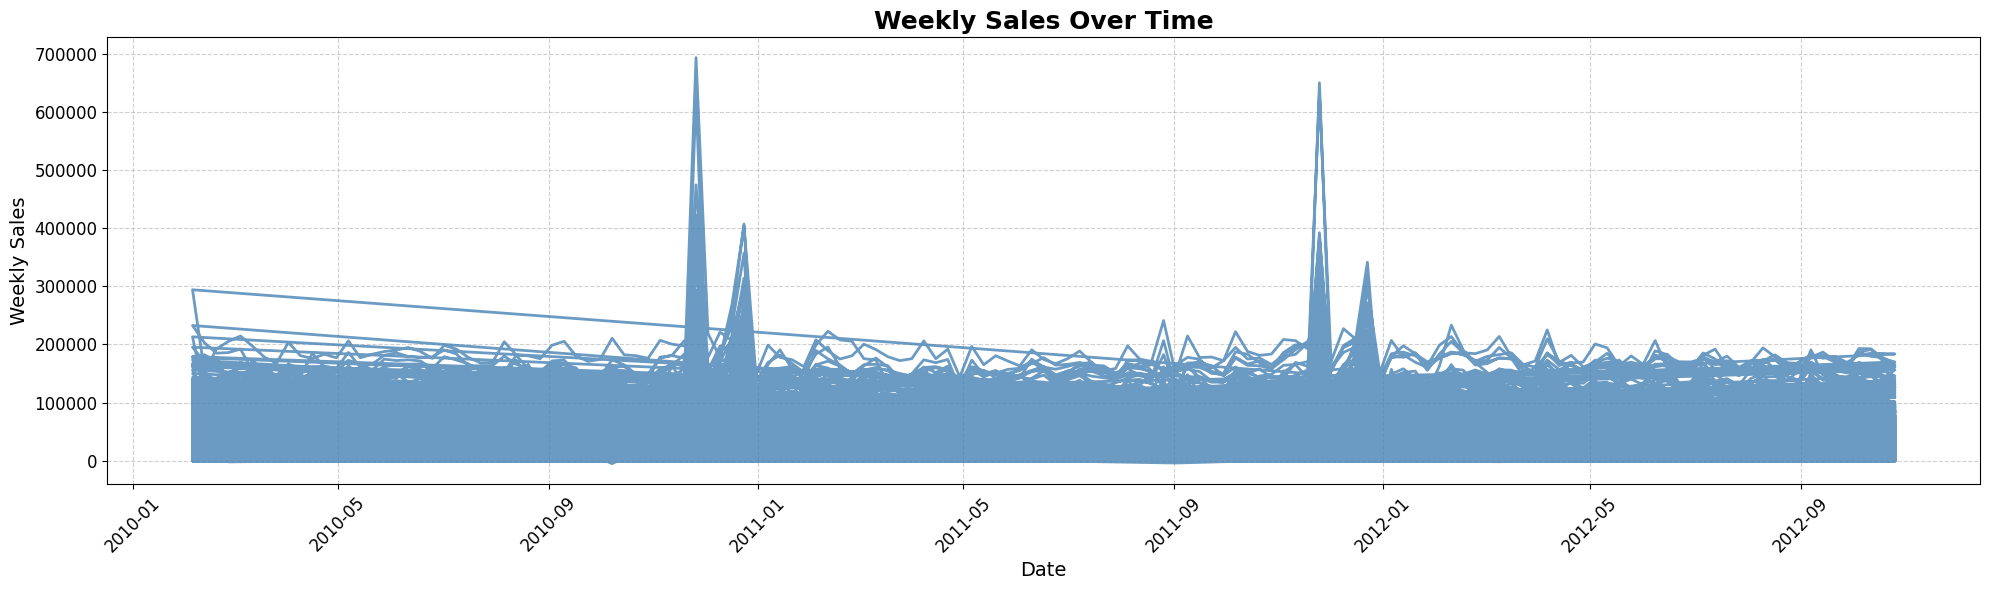

In [167]:
plt.figure(figsize=(20,6))

plt.plot(data.index, data['weekly_sales'], color="steelblue", linewidth=2, alpha=0.8)
plt.title("Weekly Sales Over Time", fontsize=18, fontweight="bold")
plt.xlabel("Date", fontsize=14)
plt.ylabel("Weekly Sales", fontsize=14)
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

`There is 2 major peaks, both at the end of the year`

**Sales by Month**

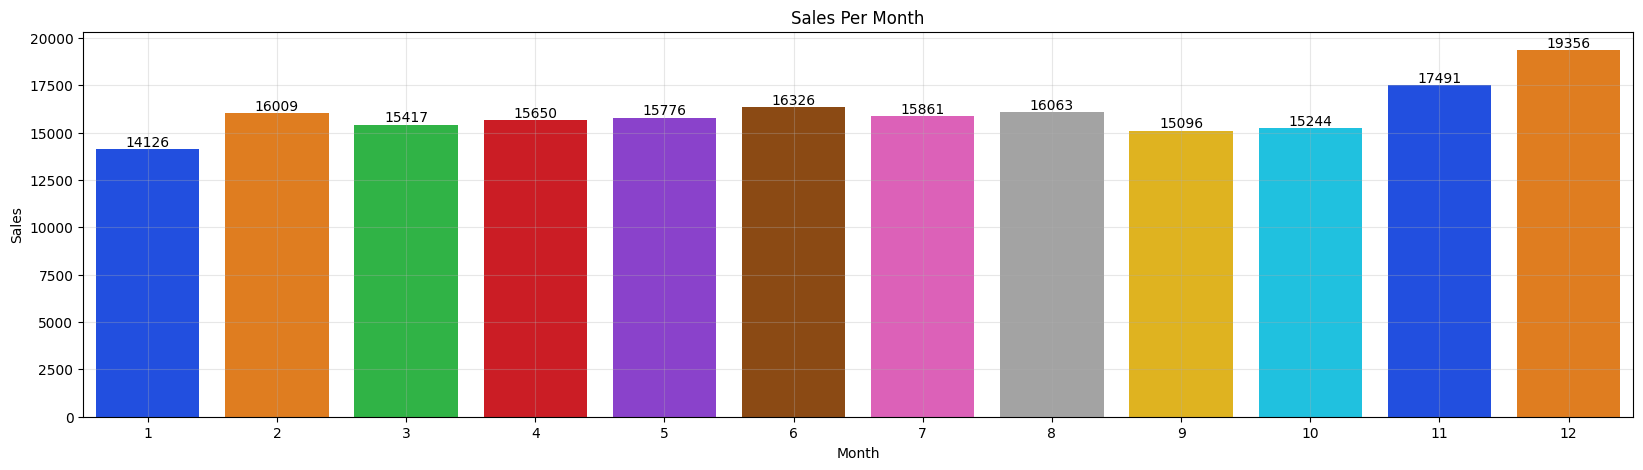

In [168]:
monthly_sales=data.groupby(data.index.month)['weekly_sales'].mean().reset_index()
plt.figure(figsize=(20,5))
ax=sns.barplot(y='weekly_sales',x='date',data=monthly_sales,palette='bright')
for container in ax.containers:
    ax.bar_label(container,fmt='%.0f')
plt.title('Sales Per Month')
plt.grid(alpha=0.3)
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

`Actually the average sales is higher in last 2 months`

**Total sales accross stores per year**

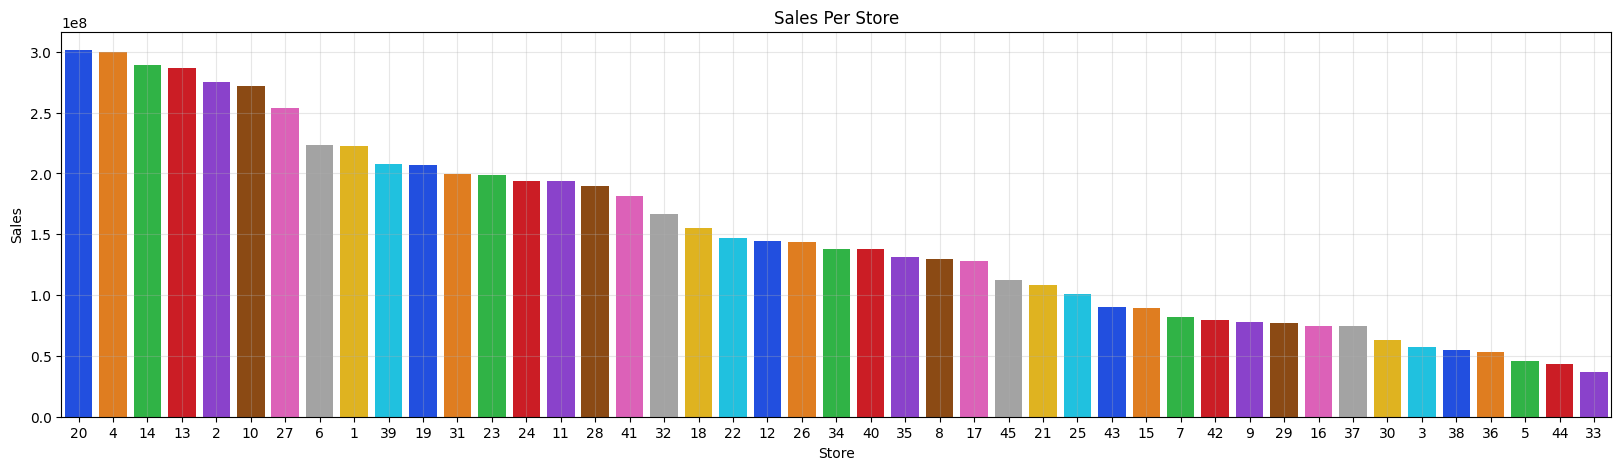

In [169]:
sales_per_store=data.groupby(['store'])['weekly_sales'].sum().reset_index()
plt.figure(figsize=(20,5))
ax=sns.barplot(y='weekly_sales',x='store',data=sales_per_store,palette='bright',order=sales_per_store.sort_values(by='weekly_sales',ascending=False)['store'])
# for container in ax.containers:
#     ax.bar_label(container,fmt='%.0f')
plt.title('Sales Per Store')
plt.grid(alpha=0.3)
plt.xlabel('Store')
plt.ylabel('Sales')
plt.show()

`Top stores with most sales`

**Average sales in holiday week**

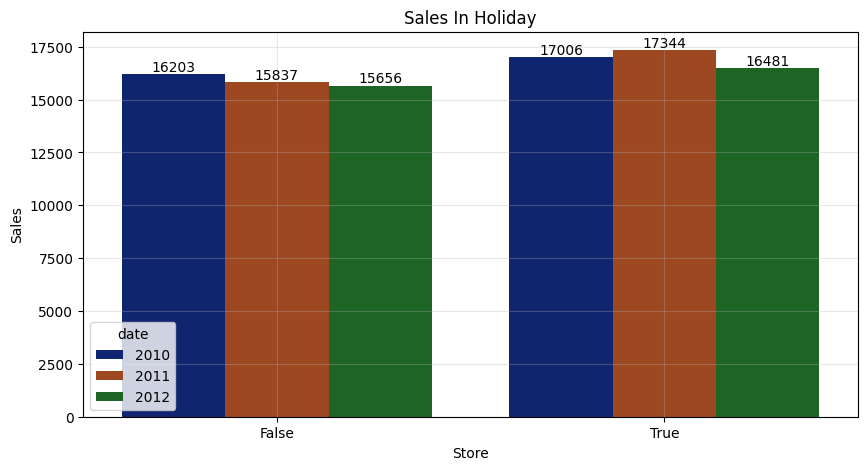

In [170]:
sales_in_holidays=data.groupby(['isholiday',data.index.year])['weekly_sales'].mean().reset_index()
plt.figure(figsize=(10,5))
ax=sns.barplot(y='weekly_sales',x='isholiday',hue='date',data=sales_in_holidays,palette='dark')
for container in ax.containers:
    ax.bar_label(container,fmt='%.0f')
plt.title('Sales In Holiday')
plt.grid(alpha=0.3)
plt.xlabel('Store')
plt.ylabel('Sales')
plt.show()

`We can see sales is more in holiday week, in each year`

**Is there any connection with temperature?**

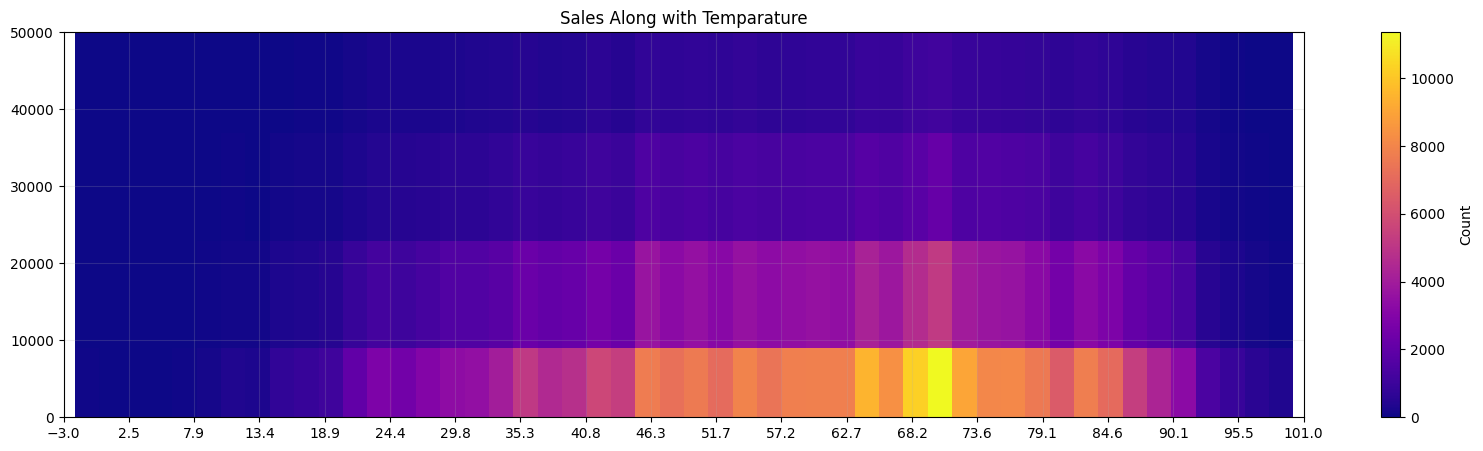

In [171]:
plt.figure(figsize=(20,5))
plt.hist2d(data["temperature"], data["weekly_sales"], bins=(50,50), cmap="plasma")
plt.colorbar(label="Count")
plt.ylim(0,50000)
plt.title('Sales Along with Temparature')
plt.xticks(np.linspace(-3,101,20))
plt.grid(alpha=0.2)
plt.show()

`Sales is comparatively less in extreme cold temperatures`

**Relationship between sales and fuel price**

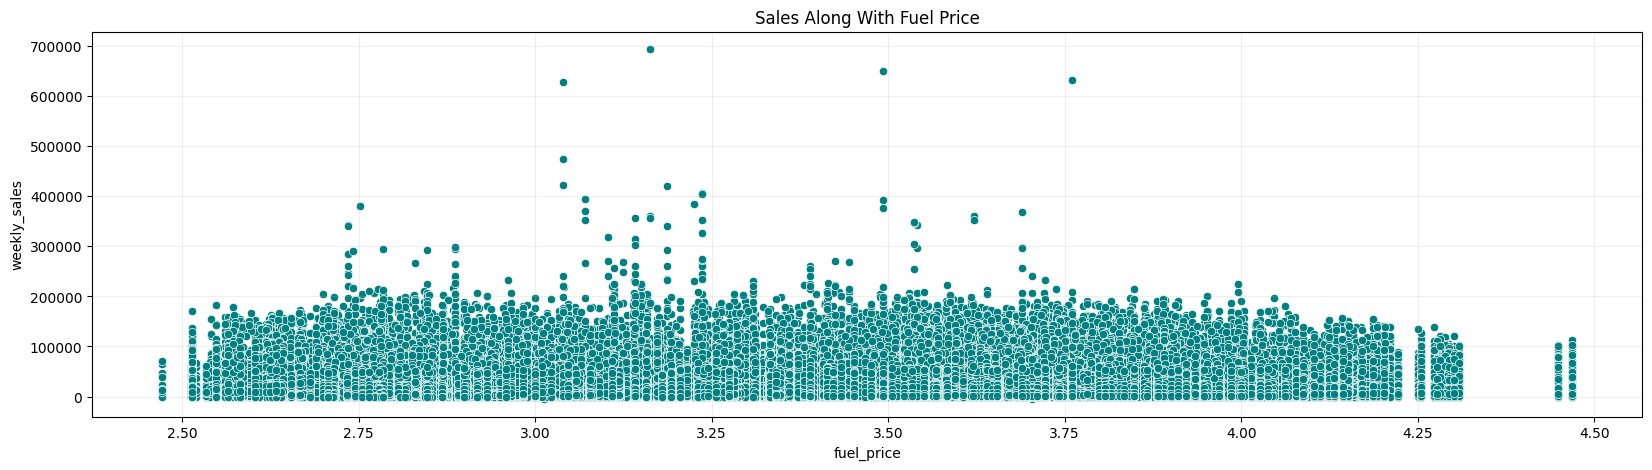

In [172]:
plt.figure(figsize=(20,5))
sns.scatterplot(x='fuel_price',y='weekly_sales',data=data,marker="o",color='teal')
plt.title('Sales Along With Fuel Price')
plt.grid(alpha=0.2)
plt.show()

`Sales is less when fuel price is higher`

**Relationship of Price with CPI**

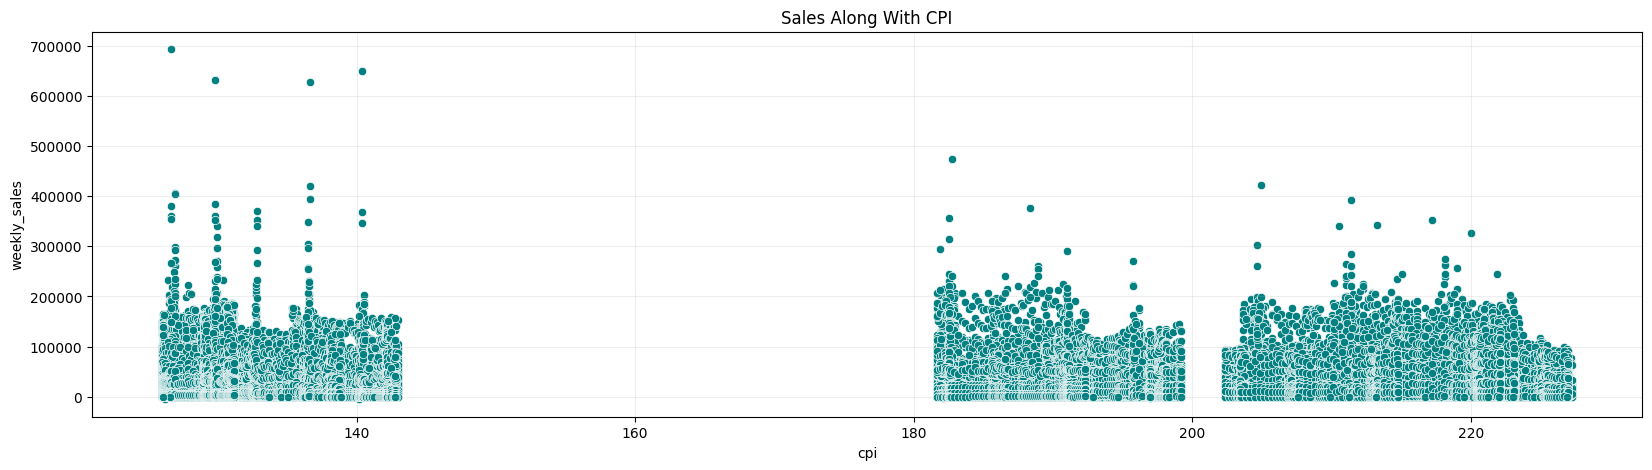

In [173]:
plt.figure(figsize=(20,5))
sns.scatterplot(x='cpi',y='weekly_sales',data=data,marker="o",color='teal')
plt.title('Sales Along With CPI')
plt.grid(alpha=0.2)
plt.show()

`CPI is divided into 3 clusters`

**Sales with Unemployment**

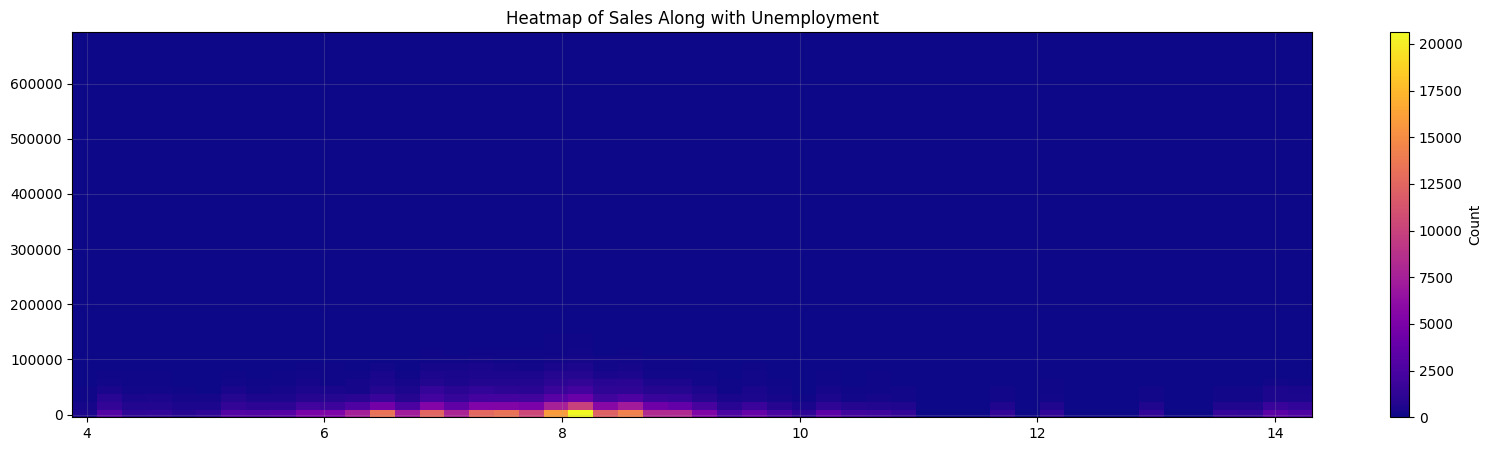

In [174]:
plt.figure(figsize=(20,5))
plt.hist2d(data["unemployment"], data["weekly_sales"], bins=(50,50), cmap="plasma")
plt.colorbar(label="Count")
plt.title('Heatmap of Sales Along with Unemployment')
plt.grid(alpha=0.2)
plt.show()

`Most of the sales are in medium unemployment rate`

**Sales over time in each year**